# Thales Manufacturing Efficiency Model Analysis

This notebook loads `Thales_Group_Manufacturing.csv`, explores the dataset, trains a baseline model, and evaluates group-aware performance.

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "Manufacturing.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,Date,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status
0,01-01-2025,00:00:00,39,Idle,74.138,3.501,8.612,10.651,0.208,7.751,477.657,0.345,14.965,Low
1,01-01-2025,00:01:00,29,Active,84.265,3.356,2.269,29.112,2.228,4.989,398.175,0.770,7.678,Low
2,01-01-2025,00:02:00,15,Active,44.280,2.080,6.144,18.357,1.639,0.457,108.075,0.987,8.198,Low
3,01-01-2025,00:03:00,43,Active,40.569,0.298,4.068,29.154,1.161,4.583,329.579,0.983,2.741,Medium
4,01-01-2025,00:04:00,8,Idle,75.064,0.346,6.226,34.029,4.797,2.288,159.114,0.573,12.101,Low


In [2]:
df.columns = df.columns.str.strip()
df['Datetime'] = pd.to_datetime(df['Date'].astype(str).str.strip() + ' ' + df['Timestamp'].astype(str).str.strip(), errors='coerce')
numeric_cols = [
    'Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW', 'Network_Latency_ms',
    'Packet_Loss_%', 'Quality_Control_Defect_Rate_%', 'Production_Speed_units_per_hr',
    'Predictive_Maintenance_Score', 'Error_Rate_%'
]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df['Machine_ID'] = df['Machine_ID'].astype(str)
df['Operation_Mode'] = df['Operation_Mode'].astype(str)
df['Efficiency_Status'] = df['Efficiency_Status'].astype(str)
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,100000,69,01-03-2025,2880,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Timestamp,100000,1440,00:00:00,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Machine_ID,100000,50,23,2092,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Operation_Mode,100000,3,Active,70054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Temperature_C,100000.0,NaN,NaN,NaN,60.04146,30.0,45.0315,60.0335,74.96725,89.999,17.323239
Vibration_Hz,100000.0,NaN,NaN,NaN,2.549959,0.1,1.323,2.549,3.776,5.0,1.414127
Power_Consumption_kW,100000.0,NaN,NaN,NaN,5.745929,1.5,3.627,5.755,7.86,10.0,2.451271
Network_Latency_ms,100000.0,NaN,NaN,NaN,25.55562,1.0,13.355,25.536,37.79625,50.0,14.12076
Packet_Loss_%,100000.0,NaN,NaN,NaN,2.493418,0.0,1.245,2.488,3.741,5.0,1.443273
Quality_Control_Defect_Rate_%,100000.0,NaN,NaN,NaN,5.008806,0.0,2.52175,5.0035,7.506,10.0,2.883666


In [3]:
print('Total rows:', len(df))
print('Status counts:', Counter(df['Efficiency_Status']))
print('Machines:', df['Machine_ID'].nunique())
print('Operation modes:', df['Operation_Mode'].unique())
print('Datetime parsed:', df['Datetime'].notna().mean())

Total rows: 100000
Status counts: Counter({'Low': 77825, 'Medium': 19189, 'High': 2986})
Machines: 50
Operation modes: <StringArray>
['Idle', 'Active', 'Maintenance']
Length: 3, dtype: str
Datetime parsed: 0.496


Efficiency_Status
3    50
Name: count, dtype: int64


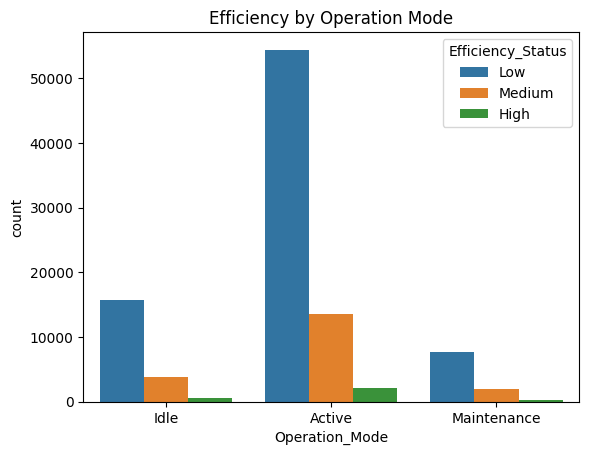

In [4]:
grouped = df.groupby('Machine_ID')['Efficiency_Status'].nunique().value_counts()
print(grouped)
sns.countplot(data=df, x='Operation_Mode', hue='Efficiency_Status')
plt.title('Efficiency by Operation Mode')
plt.show()

In [5]:
feature_cols = [
    'Operation_Mode', 'Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW',
    'Network_Latency_ms', 'Packet_Loss_%', 'Quality_Control_Defect_Rate_%',
    'Production_Speed_units_per_hr', 'Predictive_Maintenance_Score', 'Error_Rate_%'
]
model_df = df.dropna(subset=['Efficiency_Status'] + feature_cols + ['Machine_ID']).copy()
X = model_df[feature_cols].copy()
y = model_df['Efficiency_Status'].copy()
groups = model_df['Machine_ID'].copy()
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[['Operation_Mode']] = encoder.fit_transform(X[['Operation_Mode']])
X = X.fillna(X.median())
splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))
X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]
clf = RandomForestClassifier(n_estimators=120, max_depth=12, min_samples_split=40, min_samples_leaf=20, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.9999225586618137
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       752
         Low       1.00      1.00      1.00     20073
      Medium       1.00      1.00      1.00      5001

    accuracy                           1.00     25826
   macro avg       1.00      1.00      1.00     25826
weighted avg       1.00      1.00      1.00     25826

